In [8]:
import pandas as pd
import numpy as np

def clean_hardware_catalog(file_path):
    # 1. טעינת הקובץ
    df = pd.read_csv(file_path)
    print(f"טעינת דאטה הצליחה. שורות מקוריות: {len(df)}")

    # מילוני מעקב (Audit Logs)
    report = {
        "dropped_rows_missing_product_name": 0,
        "converted_unknown_to_nan": 0,
        "standardized_countries": 0,
        "imputed_and_corrected_geo": 0,
        "corrected_negative_values": 0,
        "corrupt_dates_cleared": 0,
        "corrupt_details_cleared": 0
    }

    # 2. הפיכת 'unknown' (בכל וריאציית כתיבה) ל-NaN אמיתי
    unknown_counts = df.isin(['unknown', 'UNKNOWN', 'Unknown', ' unknown']).sum().sum()
    df.replace(r'(?i)^\s*unknown\s*$', np.nan, regex=True, inplace=True)
    report["converted_unknown_to_nan"] = unknown_counts

    # 3. הסרת שורות ללא PRODUCT_NAME (קריטי לקטלוג מוצרים)
    initial_len = len(df)
    df = df.dropna(subset=['PRODUCT_NAME'])
    report["dropped_rows_missing_product_name"] = initial_len - len(df)

    # 4. ניקוי וסטנדרטיזציה של גיאוגרפיה (מדינות וערים) + דריסת שגיאות
    # נבצע מיפוי ראשוני למדינות מקוצרות
    country_mapping = {
        'United States of America': 'United States',
        'US': 'United States',
        'IN': 'India',
        'AU': 'Australia',
        'CN': 'China'
    }
    df['COUNTRY_NAME'] = df['COUNTRY_NAME'].replace(country_mapping)

    # מחסן מילים חכם שקובע את האמת המוחלטת (Source of Truth) לפי העיר
    geo_knowledge_base = {
        'San Francisco': {'STATE': 'California', 'COUNTRY_NAME': 'United States'},
        'Seattle': {'STATE': 'Washington', 'COUNTRY_NAME': 'United States'},
        'South Brunswick': {'STATE': 'New Jersey', 'COUNTRY_NAME': 'United States'},
        'Beijing': {'STATE': 'Beijing', 'COUNTRY_NAME': 'China'},
        'Bombay': {'STATE': 'Maharashtra', 'COUNTRY_NAME': 'India'},
        'Mumbai': {'STATE': 'Maharashtra', 'COUNTRY_NAME': 'India'},
        'Mexico City': {'STATE': 'Nuevo Leon', 'COUNTRY_NAME': 'Mexico'},
        'Monterrey': {'STATE': 'Nuevo Leon', 'COUNTRY_NAME': 'Mexico'},
        'Sydney': {'STATE': 'New South Wales', 'COUNTRY_NAME': 'Australia'},
        'Toronto': {'STATE': 'Ontario', 'COUNTRY_NAME': 'Canada'}
    }

# אם רשמו בטעות Southlake במדינה, נעביר את זה לעיר לפני ההשלמה
    mask_southlake_country = df['COUNTRY_NAME'] == 'Southlake'
    df.loc[mask_southlake_country, 'CITY'] = 'Southlake'

    # השלמה הדדית בסיסית בין CITY ל- WAREHOUSE_NAME אם אחד מהם חסר
    df['CITY'] = df['CITY'].fillna(df['WAREHOUSE_NAME'])
    df['WAREHOUSE_NAME'] = df['WAREHOUSE_NAME'].fillna(df['CITY'])

    geo_corrections = 0
    for city, geo_info in geo_knowledge_base.items():
        mask = (df['CITY'] == city)
        if mask.any():
            # ספירה לצורך הדו"ח: כמה שורות עבור העיר הזו הן ריקות או מכילות מדינה/מחוז לא נכונים
            wrong_or_missing = mask & (
                (df['COUNTRY_NAME'] != geo_info['COUNTRY_NAME']) |
                df['COUNTRY_NAME'].isna() |
                (df['STATE'] != geo_info['STATE']) |
                df['STATE'].isna()
            )
            geo_corrections += wrong_or_missing.sum()

            # כפיית ותיקון הערכים הנכונים מהמילון (דורס שגיאות כמו China בסן פרנסיסקו)
            df.loc[mask, 'COUNTRY_NAME'] = geo_info['COUNTRY_NAME']
            df.loc[mask, 'STATE'] = geo_info['STATE']

    report["imputed_and_corrected_geo"] = geo_corrections

    # 5. המרה למספרים ותיקון ערכים שליליים (עלויות וכמויות)
    for col in ['ACQUISITION_COST', 'SALE_COST', 'QUANTITY']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            negatives = (df[col] < 0).sum()
            report["corrected_negative_values"] += negatives
            df[col] = df[col].abs()

    # כמויות ריקות נשלים ל-0 כדי לא להרוס חישובים עתידיים
    df['QUANTITY'] = df['QUANTITY'].fillna(0)

    # 6. טיפול בתאריכים (CREATION_DATE)
    cleaned_dates = pd.to_datetime(df['CREATION_DATE'], errors='coerce')
    invalid_date_mask = (cleaned_dates.dt.year < 1990) | (cleaned_dates.dt.year > 2026) | cleaned_dates.isna()

    report["corrupt_dates_cleared"] = invalid_date_mask.sum()
    df['CREATION_DATE'] = cleaned_dates
    df.loc[invalid_date_mask, 'CREATION_DATE'] = pd.NaT

    # 7. ניקוי שדה ADDITIONAL_DETAILS (ערכים משובשים כמו 1,1,1,1)
    if 'ADDITIONAL_DETAILS' in df.columns:
        details_as_str = df['ADDITIONAL_DETAILS'].astype(str)
        corrupt_details_mask = (details_as_str.str.contains(':') == False) & df['ADDITIONAL_DETAILS'].notna()

        report["corrupt_details_cleared"] = corrupt_details_mask.sum()
        df.loc[corrupt_details_mask, 'ADDITIONAL_DETAILS'] = np.nan

    # 8. הדפסת דו"ח הבקרה (Audit Report)
    print("\n" + "="*40)
    print(" דו\"ח בקרה וניקוי נתונים - TASK 1 ")
    print("="*40)
    print(f"שורות שהוסרו לחלוטין (שם מוצר חסר): {report['dropped_rows_missing_product_name']}")
    print(f"ערכי 'unknown' שהומרו ל-Null:       {report['converted_unknown_to_nan']}")
    print(f"נתוני גיאוגרפיה שהושלמו או תוקנו:   {report['imputed_and_corrected_geo']}")
    print(f"ערכים שליליים שמתוקנים לחיוביים:     {report['corrected_negative_values']}")
    print(f"תאריכים משובשים/לא הגיוניים שנמחקו: {report['corrupt_dates_cleared']}")
    print(f"פרטים נוספים שבורים (כמו 1,1,1,1):  {report['corrupt_details_cleared']}")
    print(f"שורות סופיות שנשמרו:               {len(df)}")
    print("="*40)

    # שמירת הקובץ הנקי לשימוש ב-Task 2 והלאה
    output_path = 'hardware_catalog_clean.csv'
    df.to_csv(output_path, index=False)
    print(f"הקובץ הנקי נשמר בהצלחה תחת השם: {output_path}")

    return df

# הרצה מחדש
clean_df = clean_hardware_catalog('/content/sample_data/hardware_catalog - hardware_catalog.csv')

טעינת דאטה הצליחה. שורות מקוריות: 1112

 דו"ח בקרה וניקוי נתונים - TASK 1 
שורות שהוסרו לחלוטין (שם מוצר חסר): 17
ערכי 'unknown' שהומרו ל-Null:       2
נתוני גיאוגרפיה שהושלמו או תוקנו:   315
ערכים שליליים שמתוקנים לחיוביים:     3
תאריכים משובשים/לא הגיוניים שנמחקו: 680
פרטים נוספים שבורים (כמו 1,1,1,1):  3
שורות סופיות שנשמרו:               1095
הקובץ הנקי נשמר בהצלחה תחת השם: hardware_catalog_clean.csv


In [9]:
import pandas as pd
import numpy as np

def prepare_hardware_data(input_path):
    # 1. טעינת הקובץ הנקי מ-Task 1
    df = pd.read_csv(input_path)
    print(f"טעינת הקובץ הנקי הצליחה. שורות לעבודה: {len(df)}")

    # --- חלק א': פיצול העמודה ADDITIONAL_DETAILS ל-4 עמודות חדשות ---
    # נמיר לטקסט ונחליף ערכים חסרים במחרוזת ריקה כדי שהפיצול יעבוד חלק
    details_filled = df['ADDITIONAL_DETAILS'].fillna('')

    # פיצול לפי פסיק, והגבלת הפיצול למקסימום 4 עמודות (expand=True מייצר דאטה-פריים חדש)
    split_df = details_filled.str.split(',', expand=True)

    # ודאות שיש לנו בדיוק 4 עמודות (במקרה והיו פחות או יותר בדאטה)
    for i in range(4):
        if i not in split_df.columns:
            split_df[i] = np.nan

    # לקיחת 4 העמודות הראשונות בלבד ומתן השמות המבוקשים במשימה
    df['DETAILS_GROUP_ONE'] = split_df[0].replace('', np.nan)
    df['DETAILS_GROUP_TWO'] = split_df[1].replace('', np.nan)
    df['DETAILS_GROUP_THREE'] = split_df[2].replace('', np.nan)
    df['DETAILS_GROUP_FOUR'] = split_df[3].replace('', np.nan)

    print("-> עמודת ADDITIONAL_DETAILS פוצלה בהצלחה ל-4 קבוצות.")

    # --- חלק ב': חישוב PROFIT ו-TOTAL PROFIT ---
    # PROFIT = עלות מכירה פחות עלות רכישה (פוטנציאל רווח ליחידה בודדת)
    df['PROFIT'] = df['SALE_COST'] - df['ACQUISITION_COST']

    # TOTAL PROFIT = רווח ליחידה כפול כמות היחידות במלאי
    df['TOTAL PROFIT'] = df['PROFIT'] * df['QUANTITY']

    print("-> עמודות PROFIT ו-TOTAL PROFIT חושבו בהצלחה.")

    # --- חלק ג': חישוב PROFIT AFTER TAX (כולל לוגיקת Southlake החכמה) ---
    def calculate_profit_after_tax(row):
        country = str(row['COUNTRY_NAME']).strip()
        city = str(row['CITY']).strip()
        quantity = row['QUANTITY']
        total_profit = row['TOTAL PROFIT']

        # אם ה-TOTAL PROFIT הוא שלילי או NaN (הפסד), נחזיר אותו כפי שהוא (לא גובים מס על הפסד)
        if pd.isna(total_profit) or total_profit <= 0:
            return total_profit

        # בדיקה לפי העיר Southlake (מכיוון שהיא עיר בארה"ב ועמודת המדינה כבר נקייה)
        # חוק המס: 10% מס בסיס + 15% מס נוסף (סה"כ 25%) אם הכמות מעל 150
        if city == 'Southlake':
            tax_rate = 0.25 if quantity > 150 else 0.10
        # סין - 50% מס
        elif country == 'China':
            tax_rate = 0.50
        # מקסיקו - 30% מס
        elif country == 'Mexico':
            tax_rate = 0.30
        # אוסטרליה - 25% מס
        elif country == 'Australia':
            tax_rate = 0.25
        # שאר ארה"ב ושאר העולם - ללא מס (0% מס)
        else:
            tax_rate = 0.0

        # חישוב הרווח לאחר הורדת המס
        return total_profit * (1 - tax_rate)

    # הפעלת פונקציית המס על כל שורה ושורה בדאטה
    df['PROFIT AFTER tax'] = df.apply(calculate_profit_after_tax, axis=1)
    print("-> עמודת PROFIT AFTER tax חושבה בהצלחה בהתאם לחוקי המס.")

    # --- שמירת קובץ הפלט הסופי של המשימה ---
    output_path = 'assignment_output.csv'
    df.to_csv(output_path, index=False)
    print(f"\n המשימה הושלמה בהצלחה! הקובץ הסופי נשמר בשם: {output_path}")

    return df

# הרצת הפונקציה (משתמשת בקובץ הנקי והמתוקן שיצרנו ב-Task 1)
final_df = prepare_hardware_data('hardware_catalog_clean.csv')

טעינת הקובץ הנקי הצליחה. שורות לעבודה: 1095
-> עמודת ADDITIONAL_DETAILS פוצלה בהצלחה ל-4 קבוצות.
-> עמודות PROFIT ו-TOTAL PROFIT חושבו בהצלחה.
-> עמודת PROFIT AFTER tax חושבה בהצלחה בהתאם לחוקי המס.

 המשימה הושלמה בהצלחה! הקובץ הסופי נשמר בשם: assignment_output.csv


In [10]:
import pandas as pd
import numpy as np

# התקנת duckdb במידה ואינו מותקן
try:
    import duckdb
except ImportError:
    import os
    os.system('pip install duckdb')
    import duckdb

# ==========================================
#  Task 3.1 - Taxonomy Creation (Python)
# ==========================================

# 1. טעינת הקובץ שנוצר ב-Task 2
df_assignment = pd.read_csv('assignment_output.csv')

# 2. סינון קפדני - רק שורות שבהן TAXONOMY_INDEX הוא True
df_taxonomy = df_assignment[df_assignment['TAXONOMY_INDEX'].astype(str).str.lower() == 'true'].copy()

print(f"שורות שנמצאו עבור סיווג Taxonomy (רק True): {len(df_taxonomy)}")

# פונקציה חכמה לסיווג המוצרים ל-3 רמות
def classify_product(row):
    prod_name = str(row['PRODUCT_NAME']).upper()
    details = str(row['ADDITIONAL_DETAILS']).upper()

    if 'SSD' in prod_name or 'SSD' in details or 'EVO' in prod_name or 'SATA' in details:
        return 'Hardware', 'Storage Devices', 'Solid State Drives (SSD)'
    elif 'HDD' in prod_name or 'HARD DRIVE' in prod_name:
        return 'Hardware', 'Storage Devices', 'Hard Disk Drives (HDD)'
    elif 'INTEL' in prod_name and 'XEON' in prod_name:
        return 'Hardware', 'Compute Components', 'Server Processors (CPU)'
    elif 'CORE I' in prod_name or 'AMD RYZEN' in prod_name or 'AMD FX' in prod_name:
        return 'Hardware', 'Compute Components', 'Desktop Processors (CPU)'
    elif 'GEFORCE' in prod_name or 'GTX' in prod_name or 'RTX' in prod_name or 'AMD FIREPRO' in prod_name or 'QUADRO' in prod_name:
        return 'Hardware', 'Graphics Components', 'Graphics Processing Units (GPU)'
    elif 'RAM' in details or 'DDR4' in details or 'DDR3' in details or 'KINGSTON' in prod_name:
        return 'Hardware', 'Memory Components', 'Random Access Memory (RAM)'

    return 'Hardware', 'Other Components', 'Unclassified Hardware'

# הפעלת הסיווג
df_taxonomy[['Taxonomy Level 1', 'Taxonomy Level 2', 'Taxonomy Level 3']] = df_taxonomy.apply(
    lambda r: pd.Series(classify_product(r)), axis=1
)

# שמירת קובץ ה-Taxonomy
df_taxonomy.to_csv('taxonomy_output.csv', index=False)
print("-> קובץ taxonomy_output.csv נשמר בהצלחה עם 3 עמודות הסיווג.\n")


# ==========================================
#  Task 3.2 - Insights & SQL Queries
# ==========================================

print("="*50)
print("       ריצת שאילתות SQL - TASK 3.2 (מתוקן)")
print("="*50)

# --- שאילתה 1: רשימת ערים וכמות ההופעות שלהן (כולל סינון ערכים שהם מדינות בטעות) ---
query_1 = """
SELECT
    CITY,
    COUNT(*) as appearance_count
FROM df_assignment
WHERE CITY IS NOT NULL
  AND CITY NOT IN ('United States of America', 'India', 'China', 'US', 'IN', 'CN')
GROUP BY CITY
ORDER BY appearance_count DESC;
"""

print("\n[שאילתה 1] רשימת ערים וכמות הופעות:")
print(duckdb.query(query_1).to_df().to_string(index=False))


# --- שאילתה 2: מוצרים שנוצרו בין 2000 ל-2015 עם כמות מעל 150 ---
query_2 = """
SELECT
    PRODUCT_NAME,
    QUANTITY,
    CREATION_DATE
FROM df_assignment
WHERE CAST(strftime('%Y', CAST(CREATION_DATE AS DATE)) AS INTEGER) BETWEEN 2000 AND 2015
  AND QUANTITY > 150
ORDER BY QUANTITY DESC;
"""

print("\n[שאילתה 2] מוצרים בין 2000 ל-2015 עם כמות מעל 150 (מדגם של 5 ראשונים):")
print(duckdb.query(query_2).to_df().head(5).to_string(index=False))


# --- שאילתה 3: חילוץ גודל זיכרון ב-GB (קוד Regex מתוקן ותואם DuckDB) ---
# הסימון [0-9]+ מחפש רצף מספרים, והתנאי מוודא שזה צמוד ל-GB
query_3 = r"""
SELECT
    PRODUCT_NAME,
    ADDITIONAL_DETAILS,
    CAST(regexp_extract(ADDITIONAL_DETAILS, '([0-9]+)(?:GB|Gb|gb)', 1) AS INTEGER) as memory_size_gb
FROM df_assignment
WHERE ADDITIONAL_DETAILS LIKE '%GB%' OR ADDITIONAL_DETAILS LIKE '%gb%'
LIMIT 5;
"""

print("\n[שאילתה 3] חילוץ נפח זיכרון (GB) מתוך פרטי המוצר (מדגם של 5 שורות):")
print(duckdb.query(query_3).to_df().to_string(index=False))


# --- שאילתה 4: החברה עם הרווח הכולל הגבוה ביותר והנמוך ביותר ---
query_4 = """
WITH CompanyProfits AS (
    SELECT
        split_part(PRODUCT_NAME, ' ', 1) as company_name,
        SUM("TOTAL PROFIT") as cumulative_total_profit
    FROM df_assignment
    WHERE PRODUCT_NAME IS NOT NULL
    GROUP BY company_name
),
RankedProfits AS (
    SELECT company_name, cumulative_total_profit,
           ROW_NUMBER() OVER (ORDER BY cumulative_total_profit DESC) as rank_highest,
           ROW_NUMBER() OVER (ORDER BY cumulative_total_profit ASC) as rank_lowest
    FROM CompanyProfits
)
SELECT
    company_name,
    round(cumulative_total_profit, 2) as total_profit_usd,
    CASE
        WHEN rank_highest = 1 THEN 'Most Profitable Company'
        WHEN rank_lowest = 1 THEN 'Least Profitable Company'
    END as status
FROM RankedProfits
WHERE rank_highest = 1 OR rank_lowest = 1;
"""

print("\n[שאילתה 4] החברות עם סך הרווח המקסימלי והמינימלי:")
print(duckdb.query(query_4).to_df().to_string(index=False))

שורות שנמצאו עבור סיווג Taxonomy (רק True): 120
-> קובץ taxonomy_output.csv נשמר בהצלחה עם 3 עמודות הסיווג.

       ריצת שאילתות SQL - TASK 3.2 (מתוקן)

[שאילתה 1] רשימת ערים וכמות הופעות:
               CITY  appearance_count
             Sydney               197
            Beijing               173
South San Francisco               164
             Bombay               126
            Toronto               113
            Seattle               109
          Monterrey                94
    South Brunswick                48
          Southlake                36
      San Francisco                30
        Mexico City                 1

[שאילתה 2] מוצרים בין 2000 ל-2015 עם כמות מעל 150 (מדגם של 5 ראשונים):
              PRODUCT_NAME  QUANTITY CREATION_DATE
     Corsair CB-9060011-WW  535923.0    2009-04-01
    Kingston SA400S37/120G     353.0    2006-03-03
Gigabyte GV-N1070WF2OC-8GD     304.0    2011-01-03
         G.Skill Trident Z     275.0    2015-09-10
Gigabyte GV-N1070WF2OC-8GD  

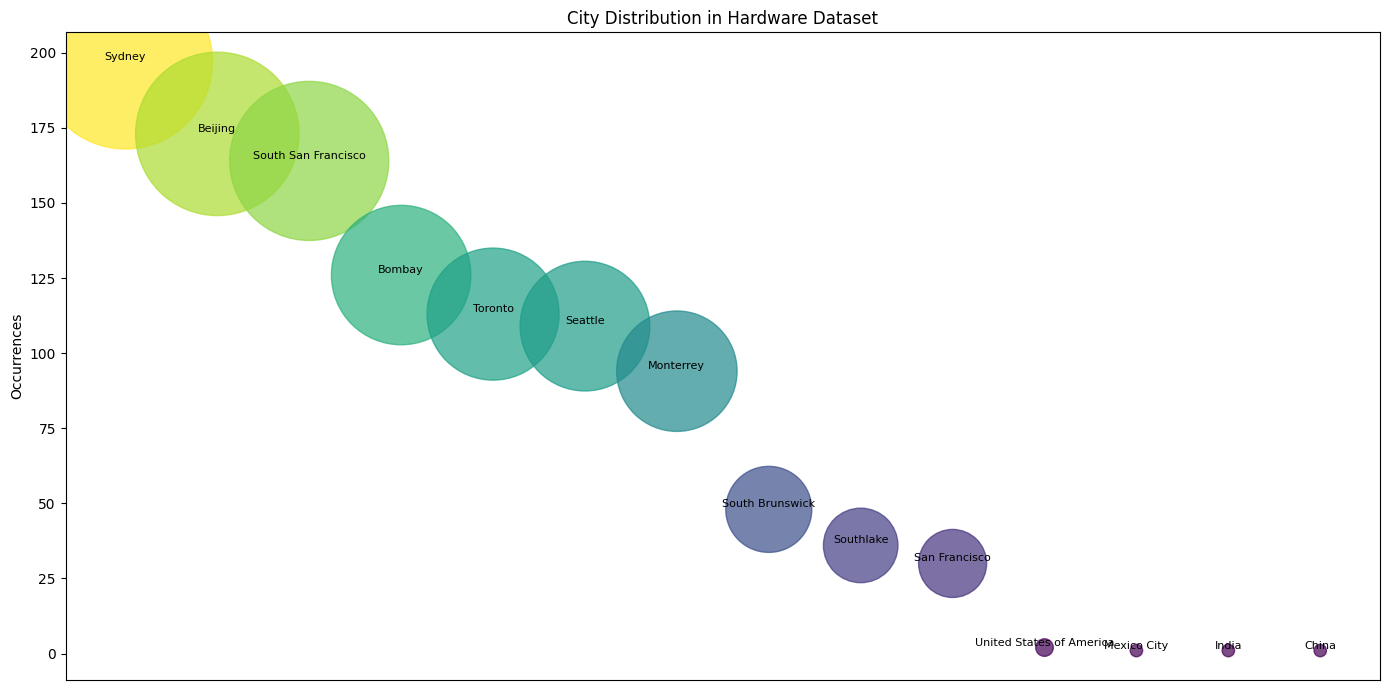

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("hardware_catalog_clean.csv")

city_counts = (
    df["CITY"]
    .dropna()
    .value_counts()
    .reset_index()
)

city_counts.columns = ["CITY", "COUNT"]

# Sort
city_counts = city_counts.sort_values(
    "COUNT",
    ascending=False
)

x = np.arange(len(city_counts))

plt.figure(figsize=(14,7))

plt.scatter(
    x,
    city_counts["COUNT"],
    s=city_counts["COUNT"]*80,
    c=city_counts["COUNT"],
    alpha=0.7
)

for i,row in city_counts.iterrows():
    plt.text(
        i,
        row["COUNT"],
        row["CITY"],
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xticks([])
plt.ylabel("Occurrences")
plt.title("City Distribution in Hardware Dataset")

plt.tight_layout()
plt.show()